# **SECTION 1: Identifying the Prediction Target**

The objective itself is to determine whether a client would subscribe to a term deposit after being contacted by the bank.

**Chosen column: **"y"****

As mentioned in session 1:
A simple objective and being/ a yes or no decision, is something that can be perfectly solved by ML.
The column y consist of label yes/no , predicting the category the data belongs to (classification)


**2 other variables:**
* **duration:** if a call lasted longer we could infer that the client accepted the offer, however we should take into account that--> **Given client and campaign information **available at the time of contact**, predict whether the client subscribes to a term deposit--> So u don't know how much time a certain call will take.

* **campaign (number of contacts performed
during the campaign) :** we could infer that if the campaign has reached out a couple of times is because they wanted to continue with the process of subscription, however this would not be a proper label for a classification problem.


# **SECTION 2: Data Loading and Exploration**

In [223]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

**Load dataset**

In [224]:
term_deposit= pd.read_csv('bank-additional.csv', sep=';')

**Inspect the structure of the dataset: number of observations, number of features, data types, and basic
summary statistics.**

In [225]:
term_deposit.info()

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   float64
 18 

**Define categorical and numerical columns for clarity**

In [226]:
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome','y']
numerical_cols = ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.conf.idx', 'cons.price.idx',
                  'euribor3m', 'nr.employed']

* 11 categorical columns such as job, marital, education, etc.
* 10 numerical columns such as age, duration, campaign, etc.
* As lecture 1 mentioned: raw data needs to be transform into tiny data, and in order to do this, it's important to identify these type of variables.

In [227]:
term_deposit.shape

(4119, 21)

The dataset contains 4119 observations and 21 columns

In [228]:
term_deposit.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


**Analyze the distribution of the target variable and comment on potential class imbalance**

In [229]:
y = term_deposit['y']
y.describe()

count     4119
unique       2
top         no
freq      3668
Name: y, dtype: object

The dataset exhibits class imbalance, with a substantially higher proportion of "no"' compared to "yes".

**Detect explicit and implicit missing values (e.g., special categories such as unknown).**

In [230]:
term_deposit.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [231]:
for col in term_deposit.select_dtypes(include=['object','string']).columns:
    print(col, term_deposit[col].value_counts().get('unknown', 0))

job 39
marital 11
education 167
default 803
housing 105
loan 105
contact 0
month 0
day_of_week 0
poutcome 0
y 0


Several categorical variables contain the category “unknown”, which represents implicit missingness. This will require explicit treatment during preprocessing.


**Visualize the distribution of at least:**
* **two numerical variables**
* **two categorical variables**

**1st numerical variable: duration** as it has a minimum and a maximum that are far away and also, a large standard deviation. It's also important to notice that it would have been an option for target variable if it wasn't for the fact that it's data that is not going to be available at the time of the call.

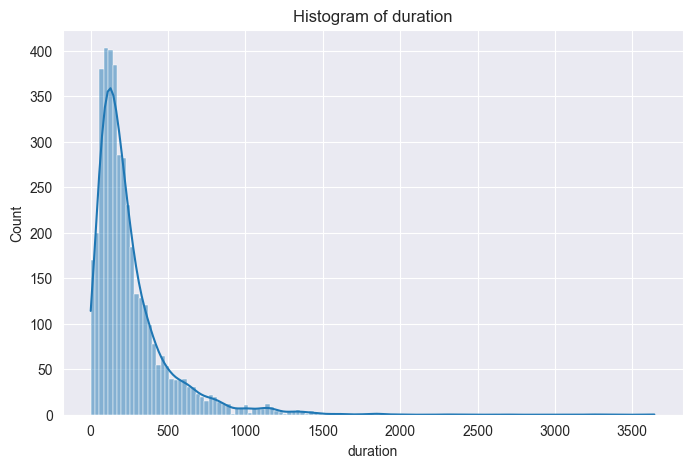

In [232]:
plt.figure(figsize=(8, 5))
sns.histplot(term_deposit["duration"], kde=True)
plt.title(f'Histogram of duration')
plt.show()

**2nd numerical variable: pdays** has 999 as the value of all its quartiles.

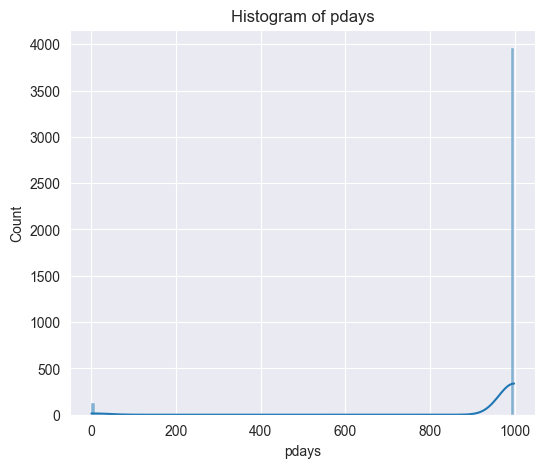

In [233]:
plt.figure(figsize=(6, 5))
sns.histplot(term_deposit["pdays"], kde=True)
plt.title(f'Histogram of pdays')
plt.show()

As suspected, both numerical variables are heavily skewed and may require transformation or special consideration.

**Categorical variables: job and education** --> rare categories could be a problem after splitting?, also; both variables contain "unknown" and implicit missing values requires explicit handling during preprocessing

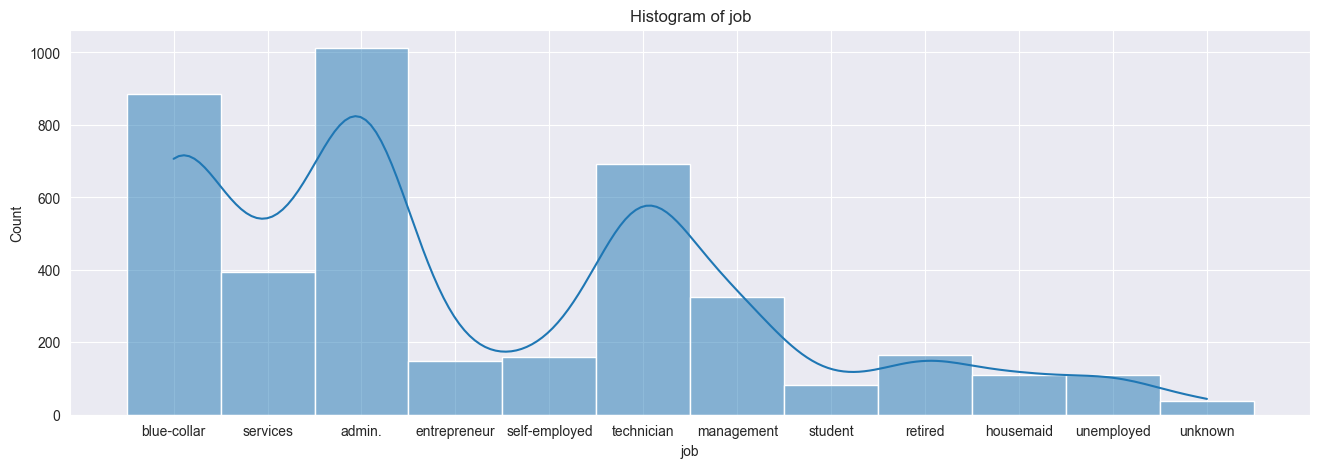

In [234]:
plt.figure(figsize=(16, 5))
sns.histplot(term_deposit["job"], kde=True)
plt.title(f'Histogram of job')
plt.show()

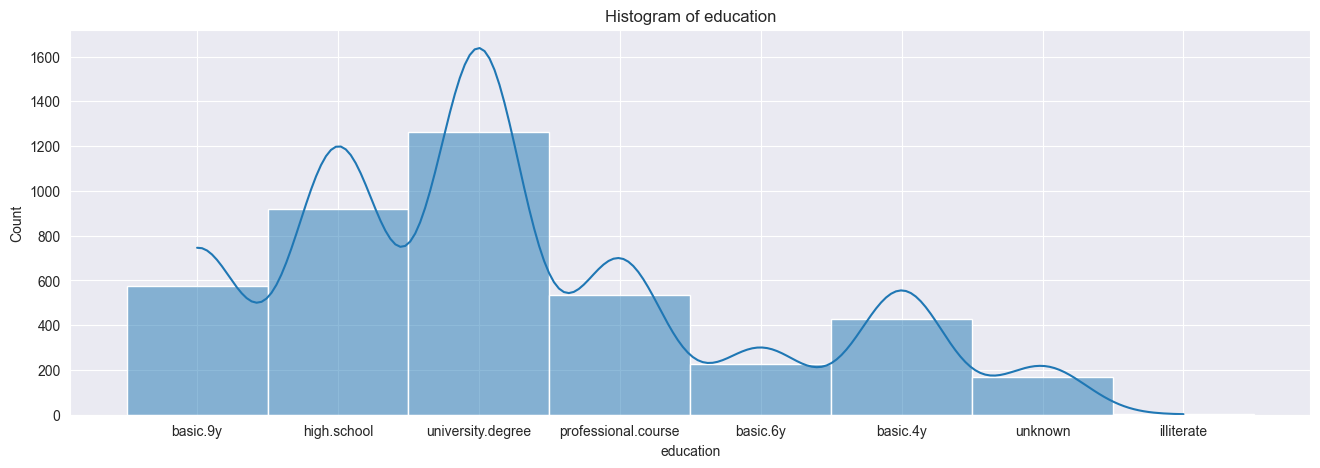

In [235]:
plt.figure(figsize=(16, 5))
sns.histplot(term_deposit["education"], kde=True)
plt.title(f'Histogram of education')
plt.show()

# **SECTION 3: Data Splitting**

As discussed in lecture 4, in order to avoid data leakage, we'll first split our data into training and test sets before computing any statistics in order to prevent the model from "lying".

**Chosen size: 60/20/20**

Data counts with 4119 observations and according to lecture 3, most frequently cited numbers for the number of training examples include 100 or 1000 times the number of classes. Given that we have 2 classes in the target variable 2x1000=2000, which is around 50% of the examples.
Since 50/50 isn't viable, 60% is chosen as training set-->2471 observations
Also, as discussed in lecture 4, shallow models as a simple Logistic Regression model doesn't improve when augmenting the training data.
Given the dataset size and the class imbalance (~12% positive class), allocating 20% to validation and 20% to testing ensures that each set contains nearly 100 positive examples.

According to lecture 4, applying stratified sampling since this data has several groups (age, job, marital, education, etc.) and we need to have examples from each of those groups in our sample. This is also important since our dataset has imbalanced classes when talking about the target. Also, in this dataset, each row represents an independent client interaction, so random stratified splitting is appropriate.

In [236]:
# Separate features and target
X = term_deposit.drop(columns=["y"])
y = term_deposit["y"]

# 1) Split out test set (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 2) Second split: training (60%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.25,
    stratify=y_train_full,
    random_state=42
)

print("Shapes:")
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

Shapes:
Train: (2471, 20) (2471,)
Val:   (824, 20) (824,)
Test:  (824, 20) (824,)


In [237]:
def show_dist(name, y_part):
    print(f"\n{name} distribution:")
    print(y_part.value_counts())
    print(y_part.value_counts(normalize=True))

show_dist("Train", y_train)
show_dist("Validation", y_val)
show_dist("Test", y_test)


Train distribution:
y
no     2200
yes     271
Name: count, dtype: int64
y
no     0.890328
yes    0.109672
Name: proportion, dtype: float64

Validation distribution:
y
no     734
yes     90
Name: count, dtype: int64
y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64

Test distribution:
y
no     734
yes     90
Name: count, dtype: int64
y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64


After splitting, the class proportions remain consistent across training, validation, and test sets. This ensures that evaluation metrics computed on validation/test are comparable to training conditions and reduces instability due to class imbalance.

# **SECTION 4: Managing Missing Values**

Now that we splitted the data, we are able to compute statistics (avoiding preprocessing leakage). According to lecture 4, "any preprocessing step that learns parameters from the data must be trained only on the training test".

So, in which variables are we going to compute statistics??

**Refer to section 2 for detecting both explicit and implicit missing values.**
* We didn't observe any NaN values, explicit missingness is null.
* Implicit missingness is present as "unknown" in categorical variables such as job, marital, education,etc. This is important because it's not random noise, it may encode useful information or reflect data collection issues.
* Sentinel numerical missingness is present in the variable "pdays" as the number 999 as shown by Andriy Burkov, people may indicate missing values with "magic numbers" which could be spotted during visual analysis.


In [238]:
#quantifying implicit missingness
for col in term_deposit.select_dtypes(include=['object','string']).columns:
    unknown_count = term_deposit[col].value_counts().get('unknown', 0)
    print(f"{col} {round(unknown_count / len(term_deposit) * 100,2)} %")

job 0.95 %
marital 0.27 %
education 4.05 %
default 19.5 %
housing 2.55 %
loan 2.55 %
contact 0.0 %
month 0.0 %
day_of_week 0.0 %
poutcome 0.0 %
y 0.0 %


Variables with larger percentages lead to an important modeling decision.
We can't remove rows since the dataset itself is already small.
Also, we can notice that the variables that have missing variables are categorical, however, replacing with most frequent category will destroy information about missingness pattern.
Therefore, we are going to treat "unknown" as its own category since we know that logistic regression can handle one-hot encoded categories as seen in lecture 8.
This is a great option since "unknown" may correlate with subscription behavior.

In [239]:
#quantifying sentinel numerical missingness
term_deposit['pdays'].value_counts().head()

pdays
999    3959
3        52
6        42
4        14
7        10
Name: count, dtype: int64

In [240]:
(term_deposit['pdays'] == 999).mean()*100

np.float64(96.11556202961884)

**Pdays--> number of days since last contact.**
We can see that the proportion of customers never contacted before is a really large percentage.
If we treated this value as numeric, the model will interpret it as a "very large number of days", even if we replace it with the median, that will destroy information about never being contacted.
So what do we do?
In this case, our best option (out of the 3 mentioned in lecture 8) is to create an indicator and transform. So we'll create a binary feature named prevoius_contact and state 1 if pdays it's equal or different than 999 and 0 if the value is 999.
This way, we'll be able to replace 999 as an NaN and then impute it with the median, keeping both features: previous_contact and pdays.

But, how and where are we supposed to do this?
A step that learns parameters from the data must be fitted only and exclusively on the training set.
On the other hand, if we were to use the whole dataset, the model will indirectly "know" something about unseen data, evaluation becoming optimistic, falling into preprocessing leakage.

Therefore:
* indicator feature will be performed in the whole dataset, it doesn't learn anything from the data. Also remember that feature engineering must be replicated as mentioned in lecture 15.
* replacing 999 as NaN will also be performed in the whole dataset
* median imputation will be performed on train set since it learns from the data distribution, median was preferred over mean due to the skewed distribution of several numerical features.
* transformation with the training median will be applied to the whole dataset, simulating behavior.

In [241]:
def transform_pdays(term_deposit):
    term_deposit = term_deposit.copy()

    # indicator feature
    term_deposit['previous_contact'] = (term_deposit['pdays'] != 999).astype(int)

    # replace sentinel value
    term_deposit['pdays'] = term_deposit['pdays'].replace(999, np.nan)

    return term_deposit

X_train = transform_pdays(X_train)
X_val = transform_pdays(X_val)
X_test = transform_pdays(X_test)

In [242]:
#train only
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

imputer = SimpleImputer(strategy='median')
imputer.fit(X_train[num_cols])

X_train[num_cols] = imputer.transform(X_train[num_cols])
X_val[num_cols] = imputer.transform(X_val[num_cols])
X_test[num_cols] = imputer.transform(X_test[num_cols])

# SECTION 5: Encoding Categorical Variables

We've previously concluded that we'll perform one hot encoding in order to consider "unknown" as its own category and don't lose any information...

As discussed in lecture 6, most ML algorithms don't take string sequences as inputs, so we must transform categorical variables into numerical feature vectors.

In order to do so, we'll first identify them in the training dataset **we are defining our data structure based on only training in order to be able to simulate unseen data as discussed in lecture 1, all of this by handling unseen categories gracefully so that we maintain stability.



In [243]:
cat_cols = X_train.select_dtypes(include=['object','string']).columns
cat_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='str')

Almost all the features except education are nominal (meaning they don't have a specific order/ "one is better than the other"). However, we notice that education is not clearly ordered since we have categories such as "unknown" or "basic.4y". Therefore, we'll treat all of these features as nominal.
According to lecture 8, when we have categories which have no natural numeric ordering, our best option is to use one-hot encoding.
It's important to notice that month and day_of_week although they don't have any "unknowns", are also an exception since they are cyclical variables, however, one-hot encoding does not impose artificial ordering, so its safe to use it.

So we fit preprocessing on the training and apply the same transformation to validation and test in order to preserve independence and prevent preprocessing leakage.

In [244]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [245]:
encoder.fit(X_train[cat_cols])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_cate

In [246]:
cat_feature_names = encoder.get_feature_names_out(cat_cols)

In [247]:
X_train_cat = encoder.transform(X_train[cat_cols])
X_val_cat = encoder.transform(X_val[cat_cols])
X_test_cat = encoder.transform(X_test[cat_cols])

In [248]:
X_train_cat_df = pd.DataFrame(X_train_cat, columns=cat_feature_names, index=X_train.index)
X_val_cat_df = pd.DataFrame(X_val_cat, columns=cat_feature_names, index=X_val.index)
X_test_cat_df = pd.DataFrame(X_test_cat, columns=cat_feature_names, index=X_test.index)

In [249]:
#concatenate so our data set is fully numeric
X_train_final = pd.concat([X_train[num_cols], X_train_cat_df], axis=1)
X_val_final = pd.concat([X_val[num_cols], X_val_cat_df], axis=1)
X_test_final = pd.concat([X_test[num_cols], X_test_cat_df], axis=1)

So what happened now is that for x categories each variable had, x columns now have been created, increasing feature space dimension. Transforming each value into an x-dimensional binary vector according to lecture 5.
For logistic regression each dummy variable will get its own coefficient, which is a numerical representation of each feature's impact on the target variable y.
It's important to highlight that one-hot encoding does not make the model nonlinear, it does allow for piecewise linear separation, that's why we were able to treat "month" and "day_of_week" with this technique.

# SECTION 6: Feature Scaling

We've managed to have all our features as numerical!! According to lecture 7, in order to train our model we need to perform feature scaling, which often leads to better model.

Continuous numerical variables are the ones who need scaling. One-hot encoded features already lie in the [0,1] range and don't forget that they represent a categorical membership.

With that being mentioned, which type of scaling is the right for our data? According ton lecture 7, normalization is often a reasonable choice for uniform features, while standardization is often a reasonable choice for roughly bell-shaped features. Therefore, we will perform standardization as it often perform well with linear models according to lecture 8.

Once again, we're performing statistics so we need to compute these only in the train set, this way avoiding preprocessing leakage. So we fit only on training and apply to validation and test sets.

In [250]:
scaler = StandardScaler()

X_train_final[num_cols] = scaler.fit_transform(X_train_final[num_cols])
X_val_final[num_cols] = scaler.transform(X_val_final[num_cols])
X_test_final[num_cols] = scaler.transform(X_test_final[num_cols])

According to lecture 8, logistic regression is sensitive to  feature's scale because we use optimization that depends on the feature's magnitude, if these magnitudes are large, they'll produce larger gradient updates. With scaling being performed, there would be a symmetric, well conditioned optimization.

**With the use of scaling we can have comparable magnitude of coefficients:**

In [251]:
X_train_final[num_cols].std()

age                 1.000202
duration            1.000202
campaign            1.000202
pdays               1.000202
previous            1.000202
emp.var.rate        1.000202
cons.price.idx      1.000202
cons.conf.idx       1.000202
euribor3m           1.000202
nr.employed         1.000202
previous_contact    1.000202
dtype: float64

Caling allows coefficient comparability since these coefficients now represent the change in log-odds associated with a 1 sd increase.

**Regularization penalty:** We know that Logistic Regression includes regularization penalty, if we do not scale these features, those who have larger numeric ranges may get penalized differently. Don't forget that Logistic Regression optimizes the log-loss and the regularization term and scaling affects both.

# SECTION 7: Feature Selection

Now that we have all of our features standardized, we can perform feature selection, since we are now able to perform an appropriate variance/correlation check with numerical useful features.

A feature has low variance if it's equal to 0 which means that the feature takes almost the same value for all observations, so it will carry no discriminative information. This will mean that it will contribute almost no signal for the gradient and its coefficient will be weakly identifiable, having little to no contribution to the optimization problem.
Given that features are standardized before modeling, a variance being < 0.01 means that the features is almost always constant. When talking about one-hot variables ,this threshold will remove categories that appear in less tan 1% of the data, which is reasonable since extremely rare categories are unlikely to generalize. We have to take into consideration that rare features can inflate coefficient magnitude and increase overfitting risk.


Feature selection is performed after splitting and preprocessing (missing-value handling, encoding, scaling) because selection relies on numeric feature representations and training-set-only statistics such as variance and correlation; performing it earlier would be either undefined (categorical strings) or would risk leakage.

**It is also important to mention that feature selection uses variance, correlation, and possibly the relation with the target, as mentioned before, any transformation that uses information from the data must be fitted in the training set only:**

In [252]:
vt = VarianceThreshold(threshold=0.01)
vt.fit(X_train_final)  # fit ONLY on training

mask = vt.get_support()

# Which columns were kept / dropped
kept_cols = X_train_final.columns[mask]
dropped_cols_var = X_train_final.columns[~mask]

print("Dropped by variance threshold:", len(dropped_cols_var))
print(dropped_cols_var.tolist())

# Create new DataFrames
X_train_var = X_train_final.loc[:, kept_cols].copy()
X_val_var   = X_val_final.loc[:, kept_cols].copy()
X_test_var  = X_test_final.loc[:, kept_cols].copy()

print("Shapes after variance:")
print(X_train_var.shape, X_val_var.shape, X_test_var.shape)

Dropped by variance threshold: 4
['job_unknown', 'marital_unknown', 'education_illiterate', 'month_dec']
Shapes after variance:
(2471, 59) (824, 59) (824, 59)


As mentioned in Lecture 8, one of the core ideas and assumptions of Logistic Regression is that there's no multicollinearity meaning that there's no features influenced by or correlated with each other.
Multicollinearity doesn't hurt prediction much but even if prediction remains good, interpretation collapses.

In [253]:
threshold = 0.9
corr = X_train_var.corr().abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop_corr = [c for c in upper.columns if any(upper[c] > threshold)]

print("Dropped by correlation:", len(to_drop_corr))
print(to_drop_corr)

X_train_fs = X_train_var.drop(columns=to_drop_corr)
X_val_fs   = X_val_var.drop(columns=to_drop_corr)
X_test_fs  = X_test_var.drop(columns=to_drop_corr)

print("Final shapes:")
print(X_train_fs.shape, X_val_fs.shape, X_test_fs.shape)

Dropped by correlation: 8
['euribor3m', 'nr.employed', 'default_unknown', 'housing_yes', 'loan_unknown', 'loan_yes', 'contact_telephone', 'poutcome_success']
Final shapes:
(2471, 51) (824, 51) (824, 51)


In [254]:
print("Start:", X_train_final.shape[1])
print("After variance:", X_train_var.shape[1], "| dropped:", len(dropped_cols_var))
print("After correlation:", X_train_fs.shape[1], "| dropped:", len(to_drop_corr))
print("Total dropped:", len(dropped_cols_var) + len(to_drop_corr))

Start: 63
After variance: 59 | dropped: 4
After correlation: 51 | dropped: 8
Total dropped: 12


As mentioned in lecture 8, when features are highly correlated, it means that many different coefficient vectors explain the data equally well, meaning x1=x2.
That would mean that many combinations of B1 and B2 would produce the same prediction, the solution not being unique and the variance of the coefficients exploding.
We know that moderate correlation is normal meaning that only extreme correlation causes real instability, therefore, we chose a threshold of 0.9.

But we don't only drop features based on model stability and interpretability, we have mentioned before in section 1 that the "duration" feature could introduce temporal leakage. So this is when you stop and think about conceptual feature removal; you have to take into consideration that you are "predicting whether the client subscribes using information available at the time of contact". In this dataset, you would only know call duration after the call ends, that's why we'll remove duration.

In [255]:
print("duration" in X_train_fs.columns)

True


In [256]:
X_train_fs = X_train_fs.drop(columns=['duration'])
X_val_fs   = X_val_fs.drop(columns=['duration'])
X_test_fs  = X_test_fs.drop(columns=['duration'])

print("New shape:", X_train_fs.shape)

New shape: (2471, 50)
